Libraries

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D,
                                     Flatten, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

print('Libraries imported!')
print(f'TensorFlow version: {tf.__version__}')

Libraries imported!
TensorFlow version: 2.21.0


Loading Data

In [2]:
path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

X_train = np.load(f'{path}\\X_train_images.npy')
X_val   = np.load(f'{path}\\X_val_images.npy')
X_test  = np.load(f'{path}\\X_test_images.npy')
y_train = np.load(f'{path}\\y_train_images.npy')
y_val   = np.load(f'{path}\\y_val_images.npy')
y_test  = np.load(f'{path}\\y_test_images.npy')

classes     = ['MildDemented', 'ModerateDemented',
               'NonDemented', 'VeryMildDemented']
num_classes = len(classes)

print('Data loaded!')
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Classes : {num_classes}')

Data loaded!
X_train : (4480, 128, 128, 3)
X_val   : (960, 128, 128, 3)
X_test  : (960, 128, 128, 3)
Classes : 4


One-Hot Encoding

In [3]:
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print('One-Hot Encoding done!')
print(f'Before : y_train[0] = {y_train[0]}')
print(f'After  : y_train_cat[0] = {y_train_cat[0]}')

One-Hot Encoding done!
Before : y_train[0] = 3
After  : y_train_cat[0] = [0. 0. 0. 1.]


Class Weights

In [4]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print('Class Weights:')
for cls, weight in zip(classes, class_weights):
    print(f'  {cls}: {weight:.3f}')

Class Weights:
  MildDemented: 1.786
  ModerateDemented: 24.889
  NonDemented: 0.500
  VeryMildDemented: 0.714


CNN Model

In [5]:
model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu',
           padding='same',
           input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu',
           padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu',
           padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), activation='relu',
           padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Flatten(),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print('Model created!')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 8,914,884 (34.01 MB)

 Trainable params: 8,912,388 (34.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

Model created!


Callback

In [6]:
save_path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{save_path}\\best_cnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('Callbacks ready!')

Callbacks ready!


Training

In [7]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05
)

datagen.fit(X_train)

print('Training started...')
print('Laptop band mat karna!')

history = model.fit(
    datagen.flow(X_train, y_train_cat,
                 batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print('Training complete!')

Training started...
Laptop band mat karna!
Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2635 - loss: 1.9312
Epoch 1: val_accuracy improved from None to 0.35000, saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_cnn_model.keras

Epoch 1: finished saving model to C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed\best_cnn_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.2855 - loss: 1.9674 - val_accuracy: 0.3500 - val_loss: 3.2192
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3069 - loss: 1.9758
Epoch 2: val_accuracy did not improve from 0.35000
70/70 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.3100 - loss: 1.8690 - val_accuracy: 0.3500 - val_loss: 4.2466
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3323 - loss: 1.7405
Epoch 3: val_accuracy did not improve from 0.35000
70/70 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.3275 - loss: 1.754

Training Graphs

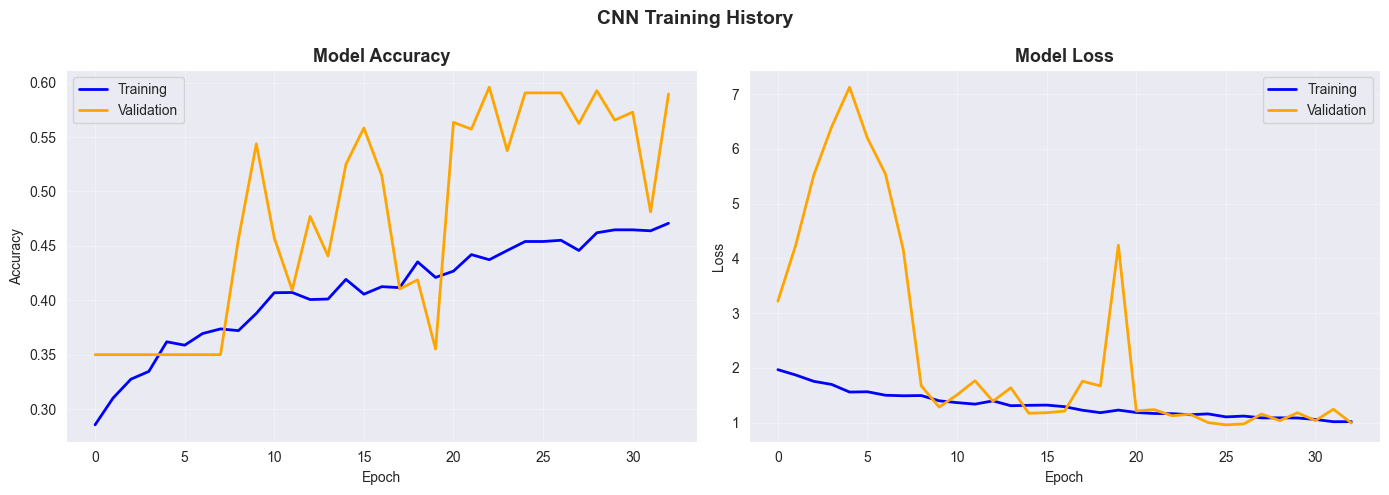

Graph saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],
             label='Training',
             color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation',
             color='orange', linewidth=2)
axes[0].set_title('Model Accuracy',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],
             label='Training',
             color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation',
             color='orange', linewidth=2)
axes[1].set_title('Model Loss',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training History',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved!')

Evaluate

In [9]:
test_loss, test_acc = model.evaluate(
    X_test, y_test_cat, verbose=0
)

y_pred_proba = model.predict(X_test)
y_pred       = np.argmax(y_pred_proba, axis=1)

f1  = f1_score(y_test, y_pred,
               average='weighted')
auc = roc_auc_score(y_test_cat, y_pred_proba,
                    multi_class='ovr',
                    average='weighted')

print('=' * 50)
print('     CNN MODEL — FINAL RESULTS')
print('=' * 50)
print(f'Accuracy : {test_acc*100:.2f}%')
print(f'F1-Score : {f1*100:.2f}%')
print(f'ROC-AUC  : {auc*100:.2f}%')
print('=' * 50)

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step
     CNN MODEL — FINAL RESULTS
Accuracy : 56.67%
F1-Score : 56.51%
ROC-AUC  : 72.50%


Confusion Matrix

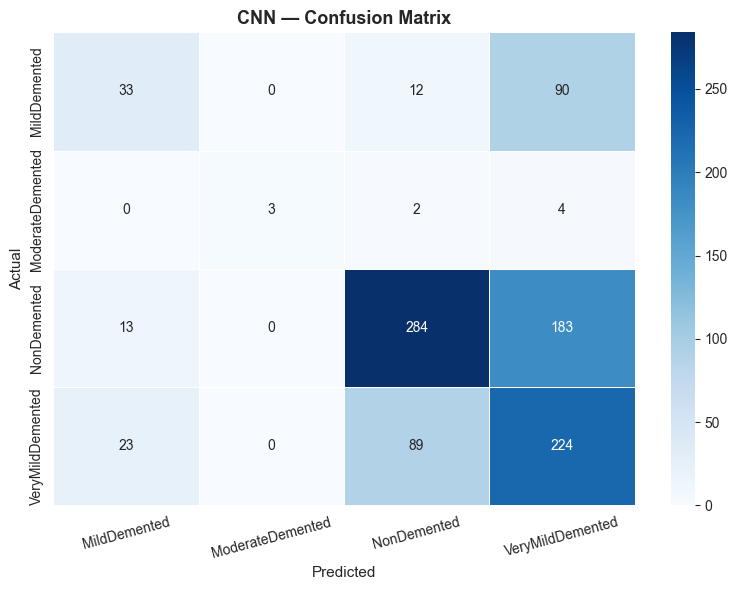

Confusion matrix saved!


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes,
            linewidths=0.5)

plt.title('CNN — Confusion Matrix',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved!')

Classification Report

In [11]:
print('Classification Report:')
print('=' * 55)
print(classification_report(
    y_test, y_pred,
    target_names=classes
))

Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.48      0.24      0.32       135
ModerateDemented       1.00      0.33      0.50         9
     NonDemented       0.73      0.59      0.66       480
VeryMildDemented       0.45      0.67      0.54       336

        accuracy                           0.57       960
       macro avg       0.66      0.46      0.50       960
    weighted avg       0.60      0.57      0.57       960


Sample Predictions

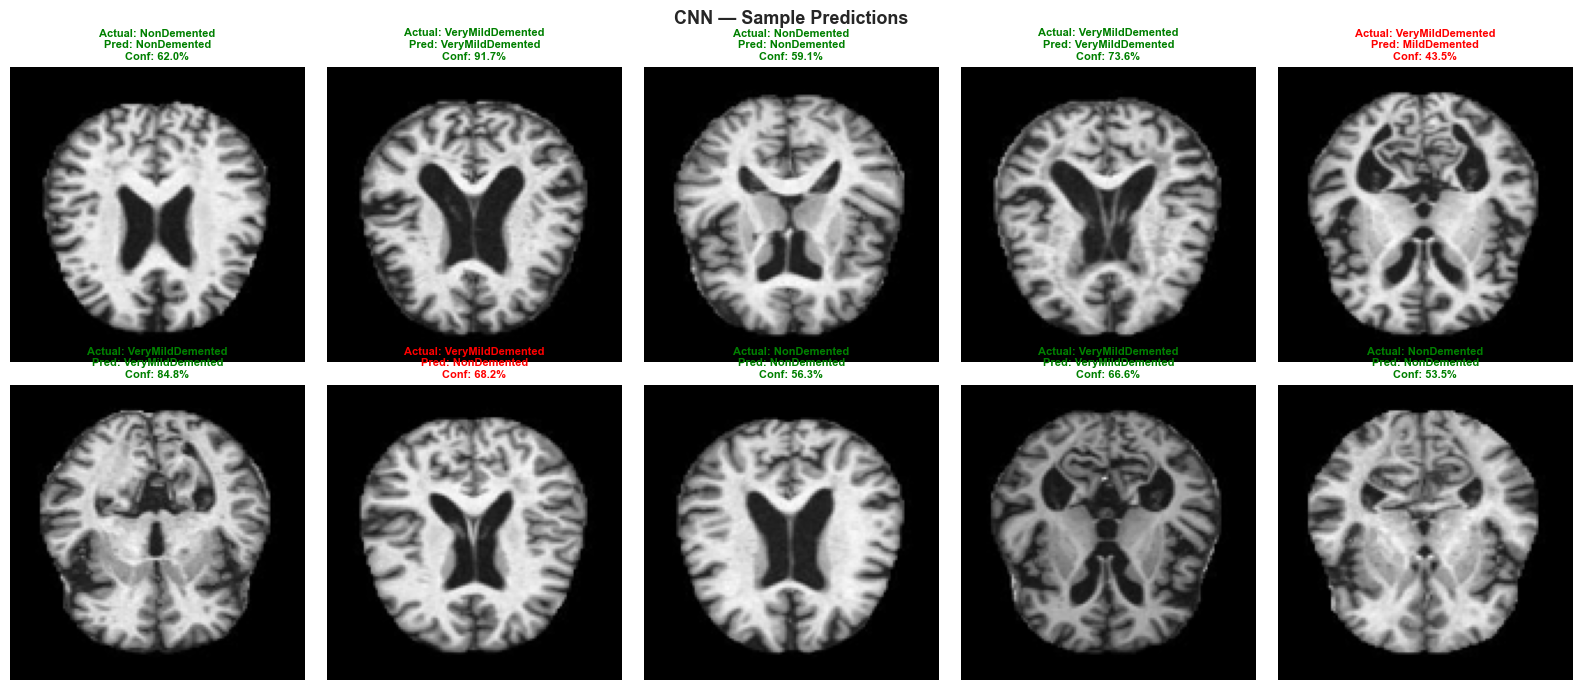

Predictions saved!


In [12]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i in range(10):
    img        = X_test[i]
    actual     = classes[y_test[i]]
    predicted  = classes[y_pred[i]]
    confidence = y_pred_proba[i][y_pred[i]] * 100

    axes[i].imshow(img)
    axes[i].axis('off')

    color = 'green' if actual == predicted else 'red'

    axes[i].set_title(
        f'Actual: {actual}\n'
        f'Pred: {predicted}\n'
        f'Conf: {confidence:.1f}%',
        fontsize=8,
        color=color,
        fontweight='bold'
    )

plt.suptitle('CNN — Sample Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_sample_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Predictions saved!')

Save Results

In [13]:
import pandas as pd

cnn_results = pd.DataFrame({
    'Model'   : ['CNN'],
    'Accuracy': [round(test_acc * 100, 2)],
    'F1-Score': [round(f1 * 100, 2)],
    'ROC-AUC' : [round(auc * 100, 2)]
})

cnn_results.to_csv(
    f'{save_path}\\cnn_results.csv',
    index=False
)

print('Results saved!')
print('=' * 50)
print('       CNN COMPLETE! ')
print('=' * 50)
print(cnn_results.to_string(index=False))
print('=' * 50)
print('Next → VGG16 Model!')

Results saved!
       CNN COMPLETE! 
Model  Accuracy  F1-Score  ROC-AUC
  CNN     56.67     56.51     72.5
Next → VGG16 Model!
